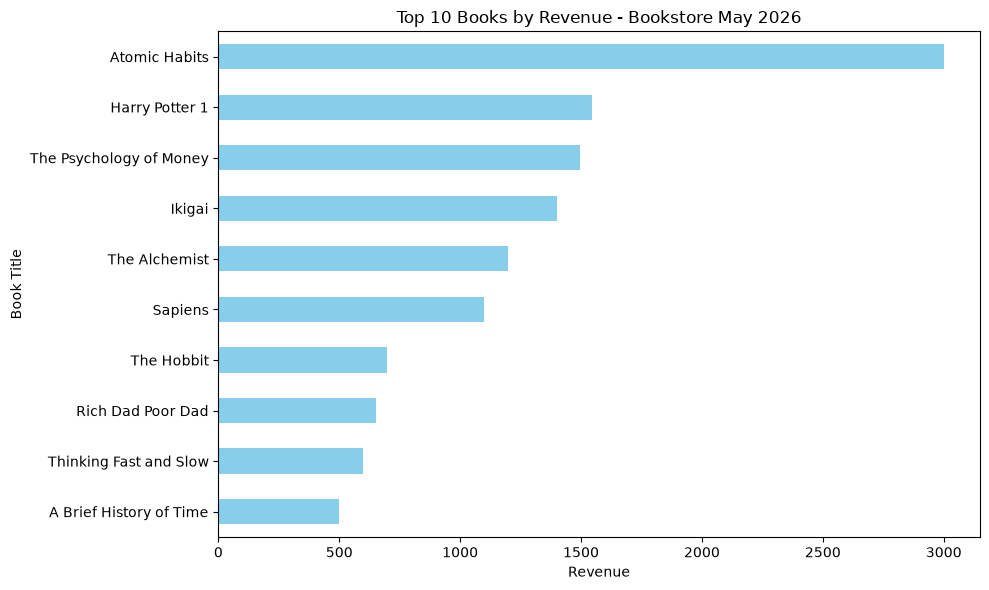

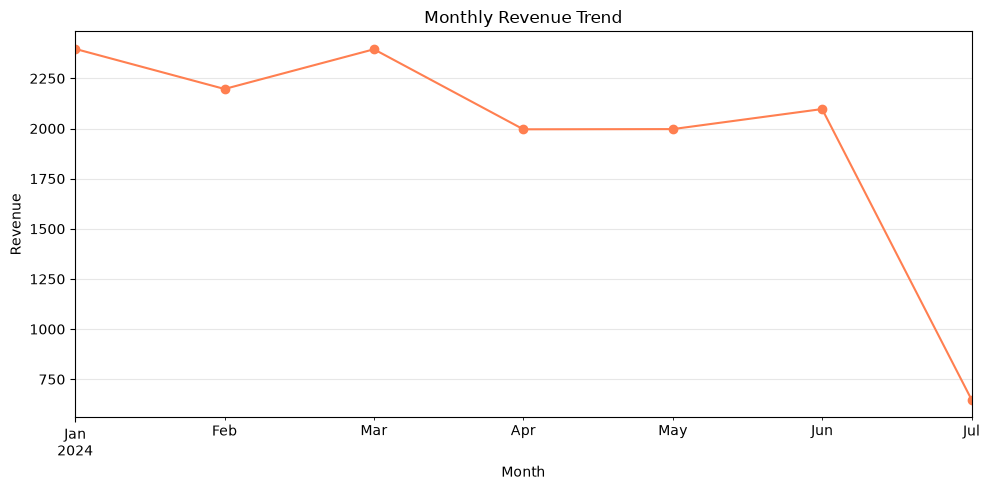

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both files
books = pd.read_csv('books.csv')
sales = pd.read_csv('sales.csv')

# Merge to get Title + Revenue together
df = pd.merge(sales, books, on='BookID')

# Convert SaleDate to datetime for trend
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

# Chart 1: Top 10 Books by Revenue
top10 = df.groupby('Title')['Revenue'].sum().nlargest(10).sort_values()
top10.plot(kind='barh', color='skyblue', figsize=(10,6))
plt.title('Top 10 Books by Revenue - Bookstore May 2026')
plt.xlabel('Revenue')
plt.ylabel('Book Title')
plt.tight_layout()
plt.savefig('top10_books.png')
plt.show()

# Chart 2: Monthly Revenue Trend
monthly = df.resample('ME', on='SaleDate')['Revenue'].sum()
monthly.plot(kind='line', marker='o', color='coral', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()